# All certain channels except for one

## 1. Descriptions
In this experiment, let's assume that we have known the performance of 3 out of 4 channels in the study with very high certainty. However, we are not quite sure about the performance of Channel 0. Let's study how the Bayesian experimental design (BED) framework can help strengthen our knowledge and reduce our uncertainty.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.functions.carryover import adstock_numpy
from bedmmm.model import MarketingMixModel
from thesis.plot import (
    plot_experiment_posterior_response_curve,
    plot_experiment_posterior_vs_ground_truth,
    plot_generated_data_on_response_curve,
    plot_posterior_response_curve,
    plot_posterior_vs_ground_truth,
)

In [2]:
N_DESIGN_POINTS = 4

plt.rcParams.update(
    {
        # "font.size": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 2. Synthetic Data Generation

In [3]:
np.random.seed(42)
generator = (
    DataGenerator(
        n_time_periods=104,  # weeks
        n_future_periods=N_DESIGN_POINTS + 13,
    )
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    .generate_target(noise=3)
)

data = generator.collect()
future_data = generator.collect("future")

media_param_df, control_param_df = generator.get_parameters()

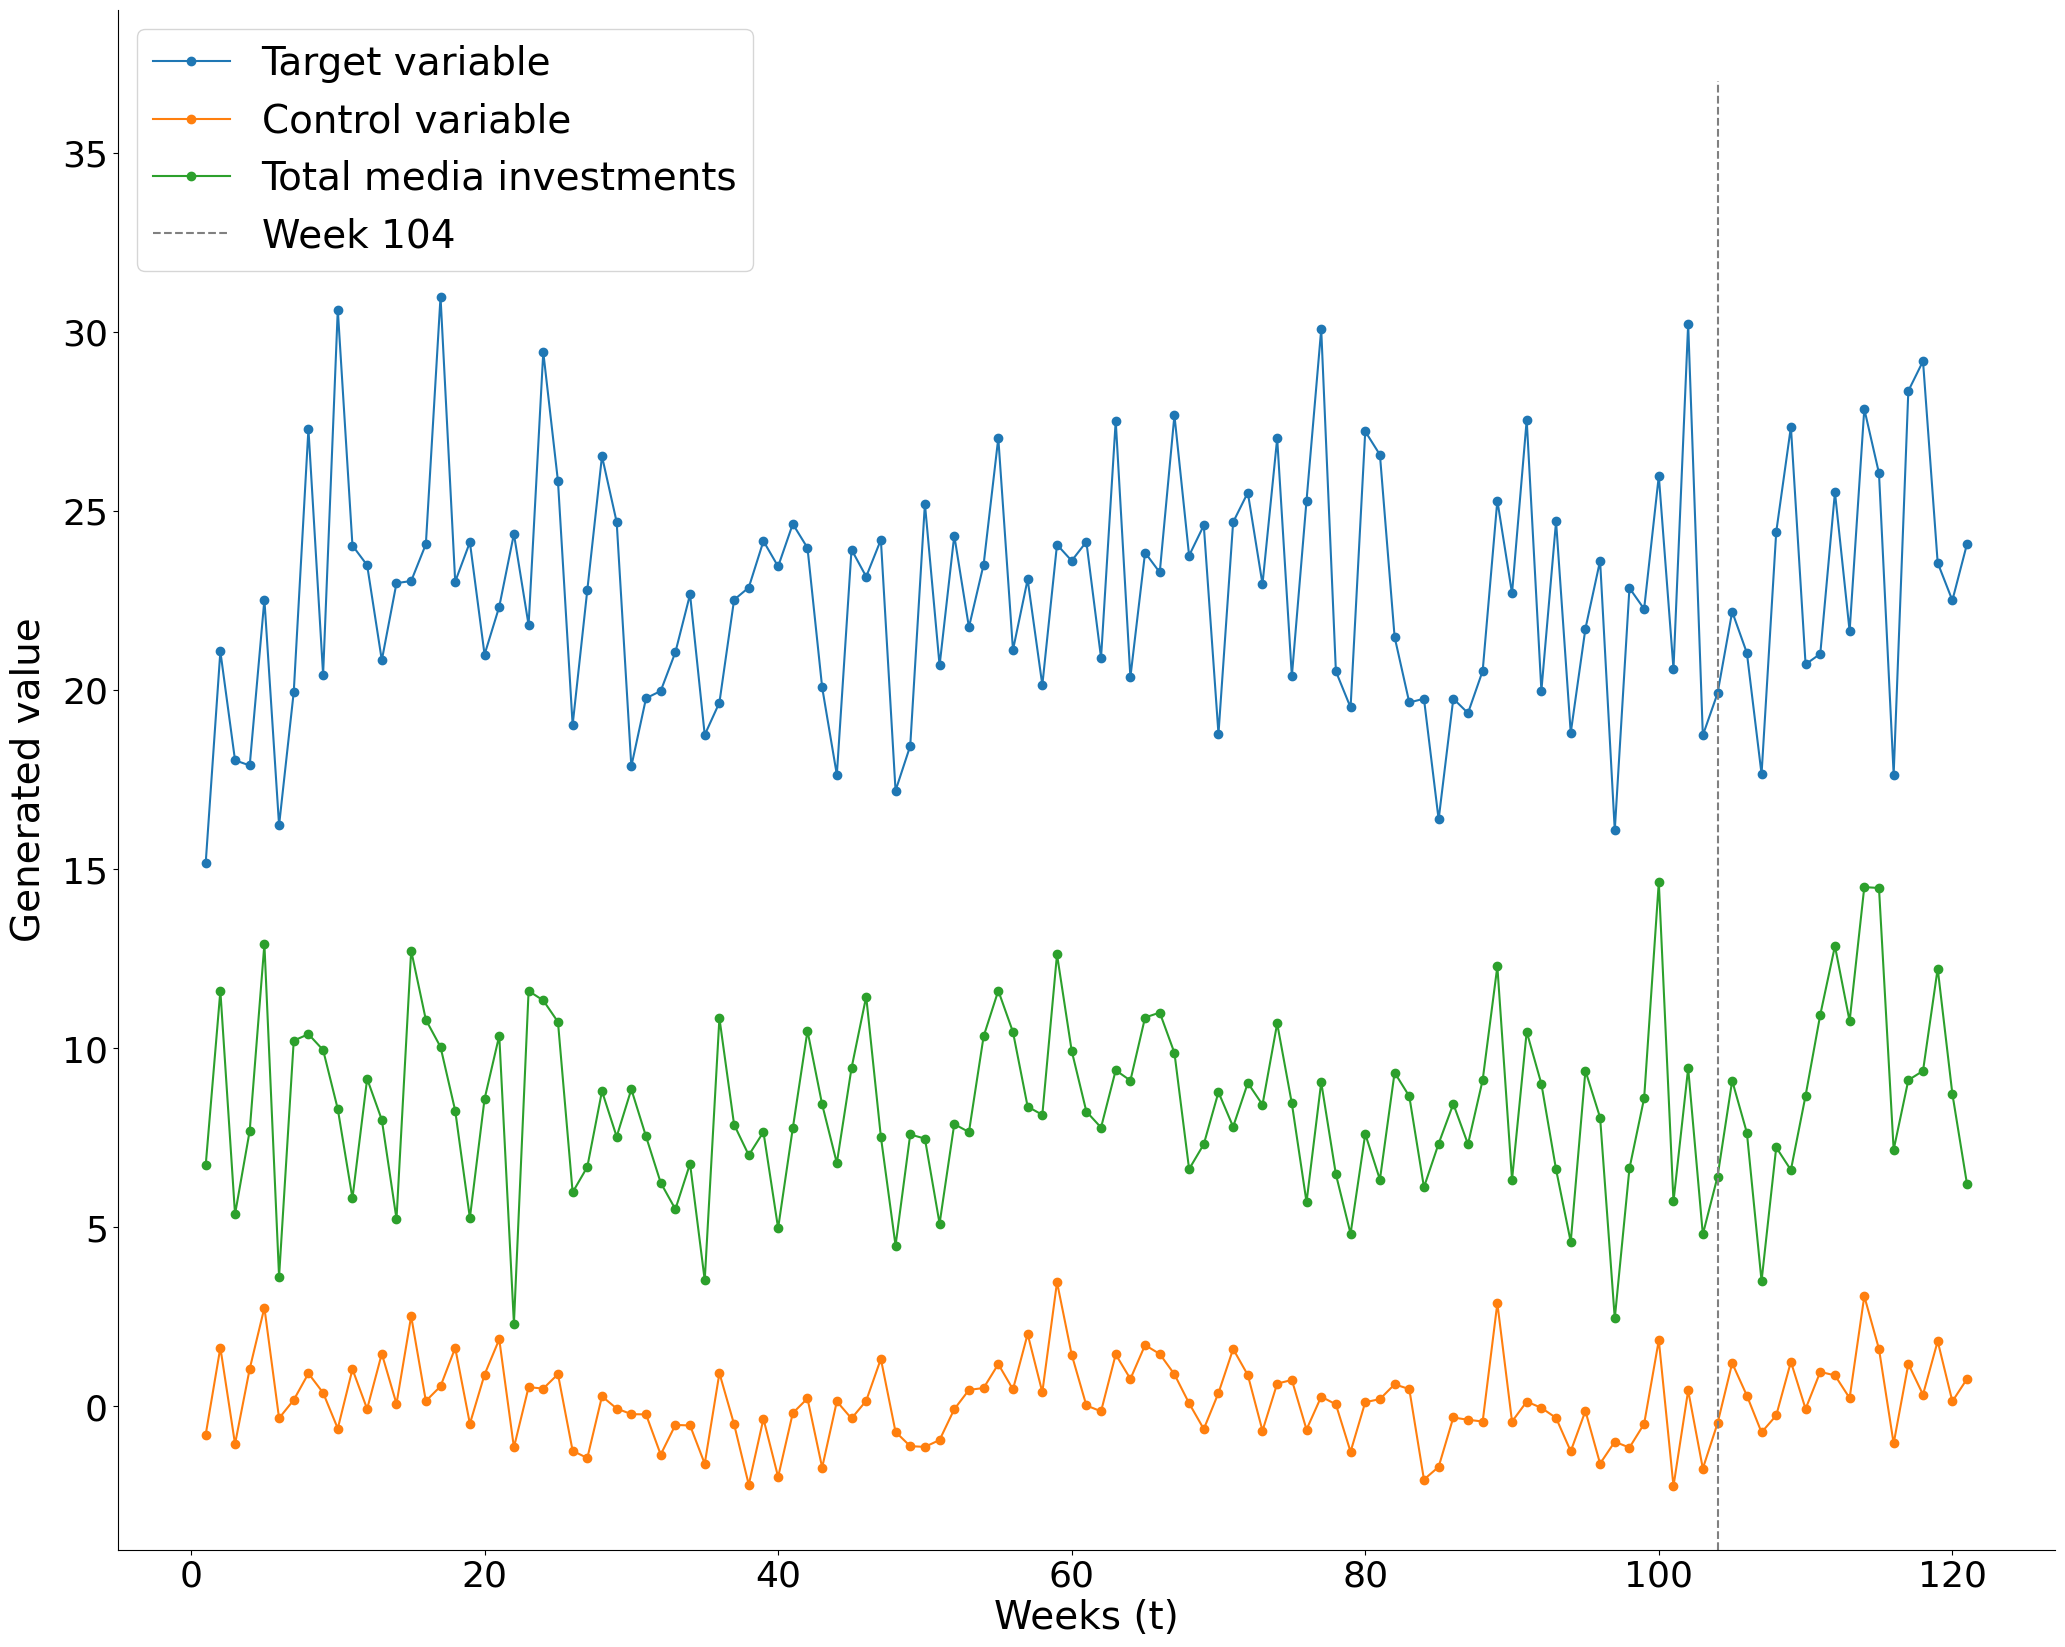

In [30]:
plt.figure(figsize=(25, 20))

synthetic_data = pl.concat([data, future_data], how="vertical")
t = np.arange(1, synthetic_data.shape[0] + 1, 1)

plt.plot(
    t, synthetic_data["y"].to_numpy(), label="Target variable", marker="o"
)
plt.plot(
    t,
    synthetic_data["control_0"].to_numpy(),
    label="Control variable",
    marker="o",
)
plt.plot(
    t,
    synthetic_data.select(cs.starts_with("media_")).to_numpy().sum(axis=1),
    label="Total media investments",
    marker="o",
)
plt.vlines(
    x=104,
    ymin=-4,
    ymax=37,
    colors="gray",
    linestyles="dashed",
    label="Week 104",
)

plt.xlabel("Weeks (t)", size=28)
plt.ylim(-4, 39)
plt.ylabel("Generated value", labelpad=10, size=28)
plt.legend(loc="upper left", fontsize=28)
plt.tick_params(axis="both", which="major", labelsize=26)

plt.show()

In [31]:
plt.style.use("_mpl-gallery")

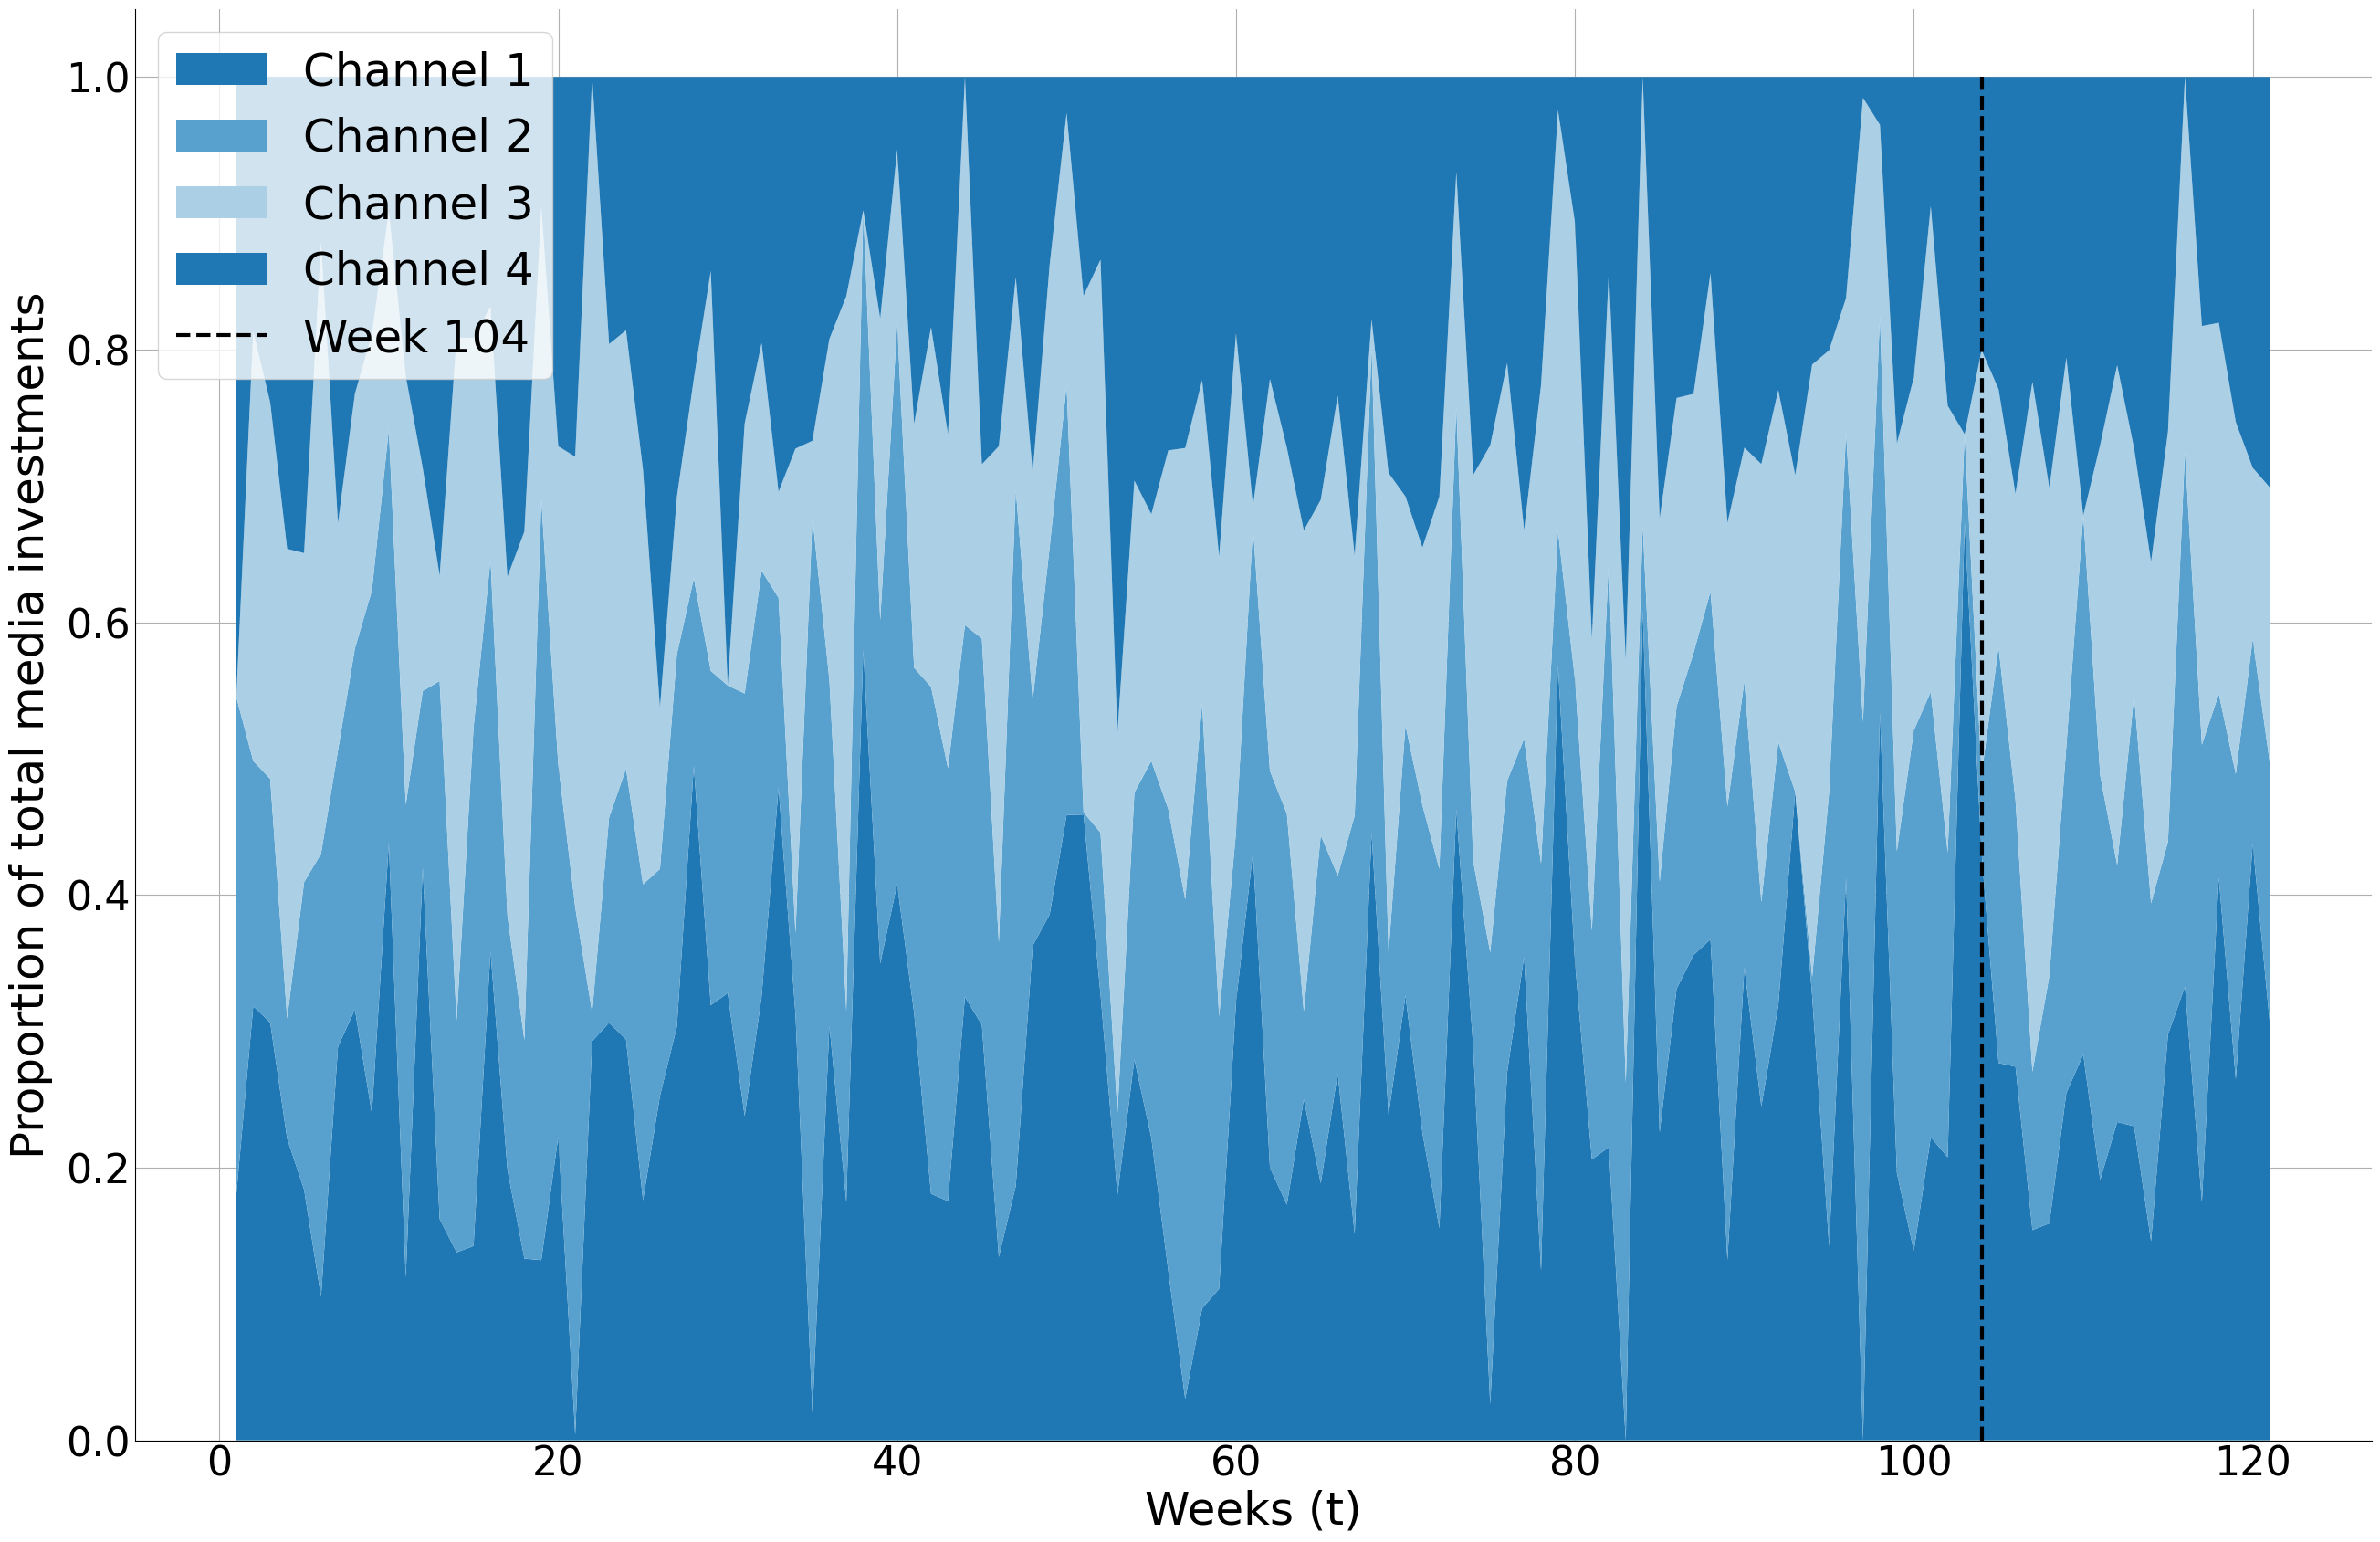

In [36]:
media_data = (
    synthetic_data.select(cs.starts_with("media_")).to_numpy().transpose()
)

plt.figure(figsize=(25, 16))

plt.stackplot(
    synthetic_data.with_row_index("time_index")["time_index"].to_numpy() + 1,
    media_data / media_data.sum(axis=0)[np.newaxis, :],
    labels=[
        f"Channel {i + 1}"
        for i in range(
            synthetic_data.select(cs.starts_with("media_")).shape[1]
        )
    ],
)
plt.vlines(
    x=104,
    ymin=0,
    ymax=1,
    colors="black",
    linestyles="dashed",
    label="Week 104",
    linewidth=3,
)

plt.xlabel("Weeks (t)", size=36)
# plt.xlim(-2, )
plt.ylabel("Proportion of total media investments", labelpad=10, size=36)
plt.legend(loc="upper left", fontsize=36)
plt.tick_params(axis="both", which="major", labelsize=32)
plt.show()

In [7]:
plt.style.use("default")

## 3. Fit a Marketing Mix Model (MMM)

Let's fit a MMM where the prior distributions of the Media channel 0 are chosen to reflect the high uncertainty while the prior distributions of all other channels are tight.

In [8]:
model_config = {
    #
    # Media channel 0 priors (high uncertainty)
    "retention_rate_lb_0": 0.1,
    "retention_rate_ub_0": 0.9,
    "shape_mu_0": 5,
    "shape_sigma_0": 3,
    "saturation_mu_0": 7,
    "saturation_sigma_0": 3,
    #
    # Media channel 1 priors (tight priors)
    "retention_rate_lb_1": 0.19,
    "retention_rate_ub_1": 0.21,
    "shape_mu_1": 1,
    "shape_sigma_1": 0.1,
    "saturation_mu_1": 2,
    "saturation_sigma_1": 0.1,
    #
    # Media channel 2 priors (tight priors)
    "retention_rate_lb_2": 0.79,
    "retention_rate_ub_2": 0.81,
    "shape_mu_2": 3,
    "shape_sigma_2": 0.1,
    "saturation_mu_2": 6,
    "saturation_sigma_2": 0.1,
    #
    # Media channel 3 priors (tight priors)
    "retention_rate_lb_3": 0.79,
    "retention_rate_ub_3": 0.81,
    "shape_mu_3": 1,
    "shape_sigma_3": 0.1,
    "saturation_mu_3": 2,
    "saturation_sigma_3": 0.1,
    #
    # Control
    "gamma_mu_0": 1.0,
    "gamma_sigma_0": 1.0,
    #
    # Baseline
    "baseline_mu": 10.0,
    "baseline_sigma": 0.1,
    #
    # Observation noise
    "obs_sigma": 3,
}
sampler_config = {
    "draws": 15_000,
    "tune": 5_000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.95,
}

Let's first fit a model that represents our current state of knowledge (after having observed the historical data).

In [9]:
model = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 191 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [10]:
summary_df = az.summary(idata)
# az.plot_trace(idata, figsize=(15, 20));

In [11]:
summary_df.reset_index().query(
    "index.isin(['retention_rates[0]', 'shapes[0]', 'saturations[0]'])"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
105,retention_rates[0],0.329,0.145,0.100,0.578,0.000,0.001,83745.0,32583.0,1.0
109,shapes[0],6.319,2.067,2.499,10.189,0.007,0.009,83906.0,37653.0,1.0
113,saturations[0],7.959,1.916,4.446,11.526,0.006,0.008,86863.0,40519.0,1.0


### 3.1 Comparison between Posterior Distributions and Ground Truth

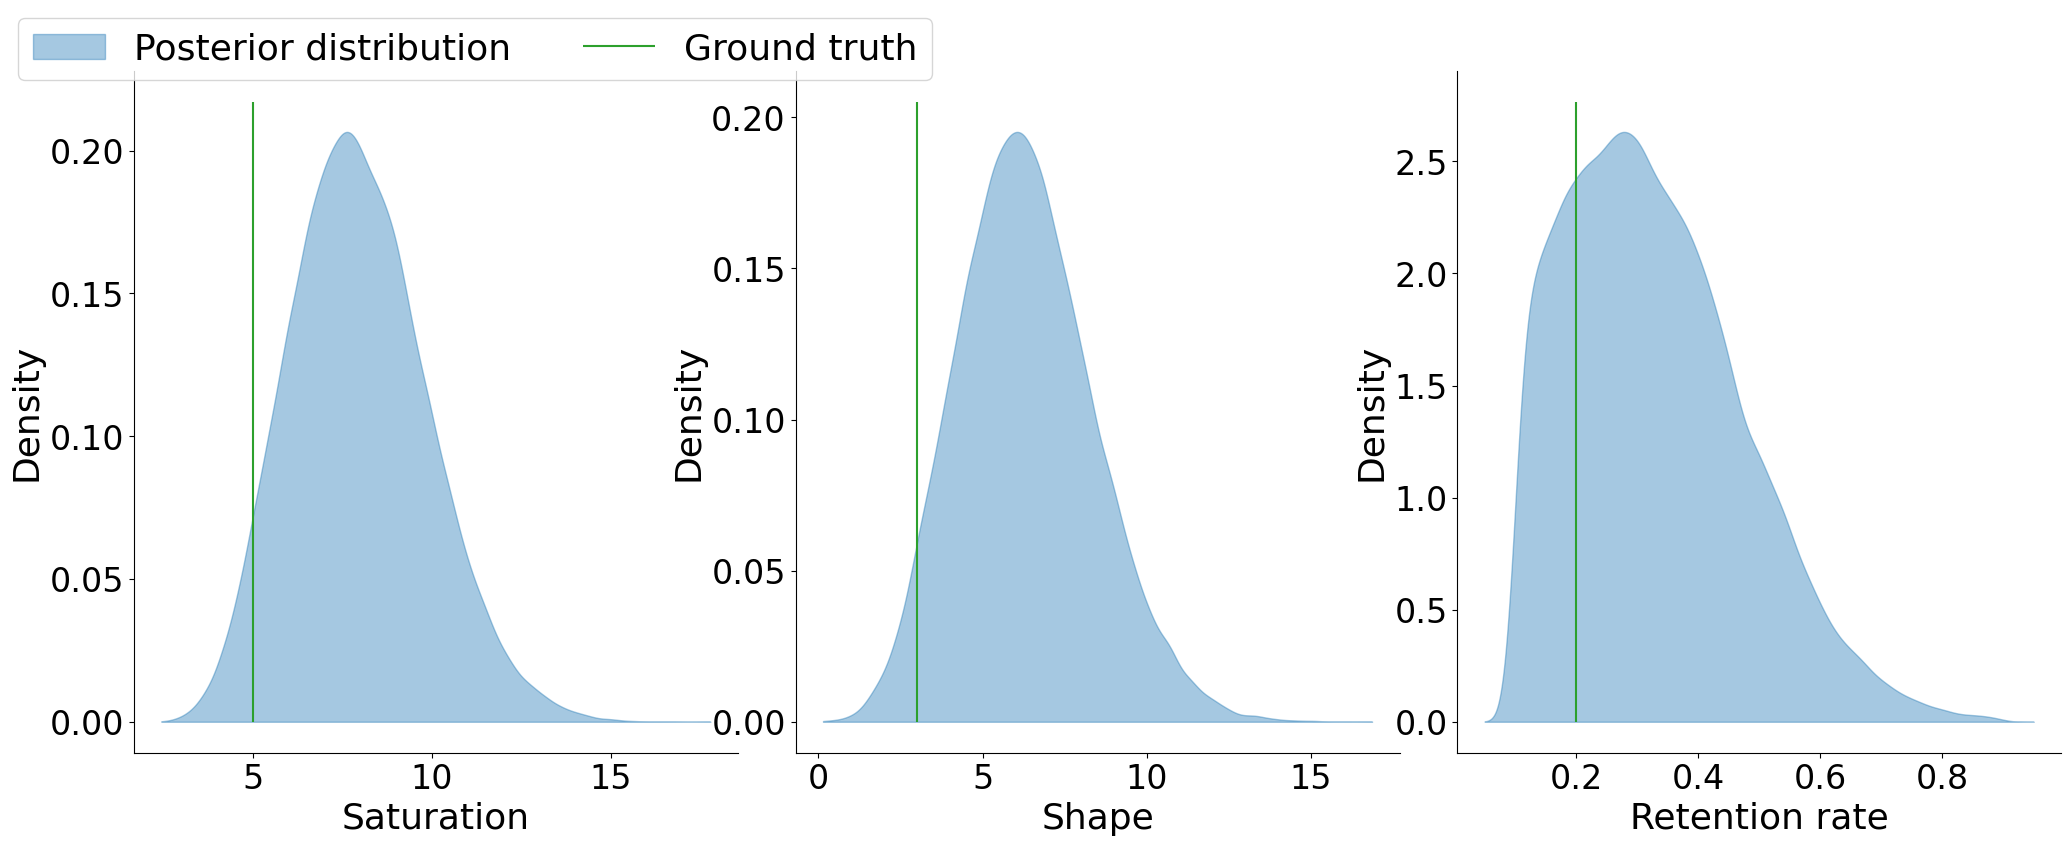

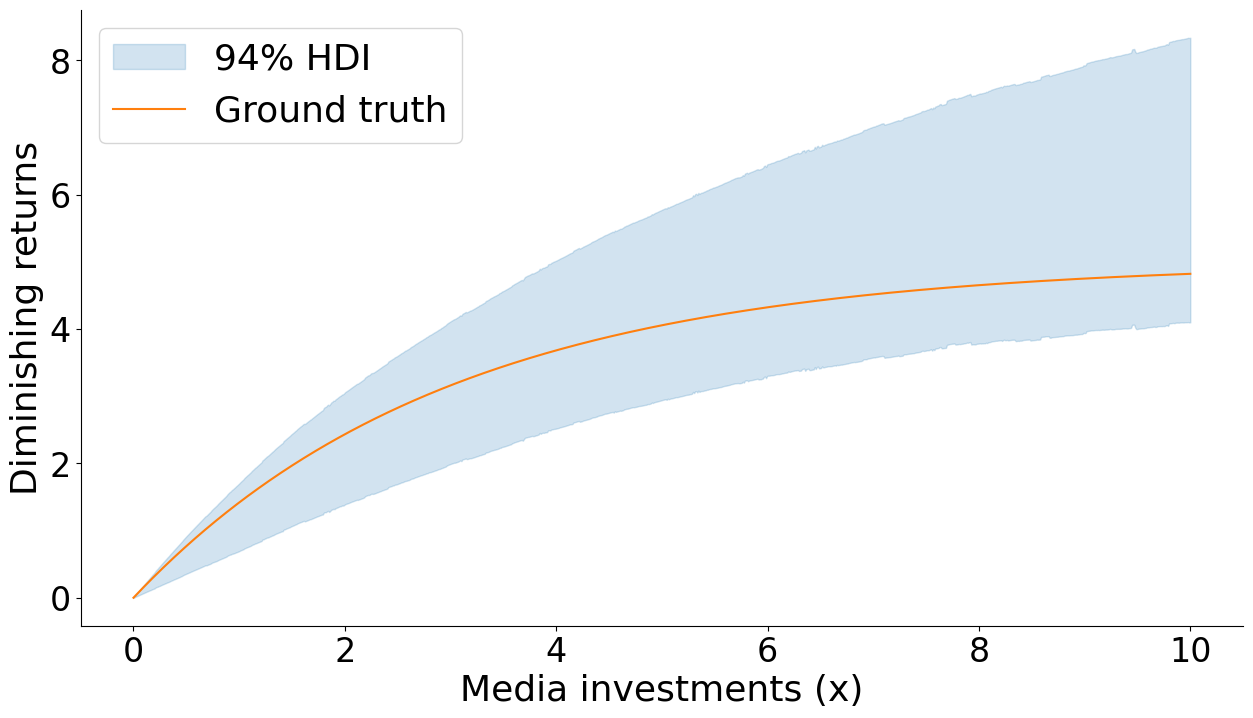

In [12]:
plot_posterior_vs_ground_truth(
    idata, media_param_df, media_feature_names=["media_0"]
)
plot_posterior_response_curve(
    idata, media_param_df, media_feature_name="media_0"
)

## 4. Bayesian Experiment Design (BED)

When generating the synthetic data, a dataset, which we call "future data", is also generated along with the data used to fit the model above. "Future data" is not used to fit the model but considered as the budget planning for marketing investments. This helps us quantify the difference between the investments recommended in the optimal experiment and the planned budget (which the marketers are already comfortable of investing).

In [13]:
future_data = generator.collect(data_type="future")

### 4.0 What if we don't run any experiments?

Let's fit a model with 104 + 4 + 13 weeks of data without running any experiments at all. This model represents our state of knowledge without the integration of the BED framework.

In [14]:
data_without_dhat = pl.concat([data, future_data], how="vertical")

model_without_dhat = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_without_dhat = model_without_dhat.fit(
    data_without_dhat.drop(["y"]).to_pandas(),
    data_without_dhat["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 211 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [15]:
summary_without_dhat_df = az.summary(idata_without_dhat)

In [16]:
summary_without_dhat_df.reset_index().query(
    "index.isin(['retention_rates[0]', 'shapes[0]', 'saturations[0]'])"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.323,0.150,0.100,0.585,0.001,0.001,75352.0,33190.0,1.0
126,shapes[0],6.236,2.103,2.273,10.074,0.008,0.009,67192.0,36190.0,1.0
130,saturations[0],7.791,1.897,4.333,11.300,0.007,0.008,68035.0,40255.0,1.0


### 4.1 Optimize for response curve parameters

In [17]:
future_control_vars = (
    future_data.slice(0, 1)
    .select(cs.starts_with("control_"))
    .to_numpy()
    .flatten()
)
future_media_data_df = future_data.slice(0, 4).select(cs.starts_with("media_"))

channel_0_total_future_budget = future_media_data_df.to_numpy()[:, 0].sum()

In [18]:
d_hat_curve_param = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        # Let's assume that we only do the experimnent on the Channel 0.
        lower_bound=(
            future_media_data_df.with_columns(
                pl.lit(0.0).alias("media_0")
            ).to_numpy()
        ),
        upper_bound=(
            future_media_data_df.with_columns(
                pl.lit(channel_0_total_future_budget * 2).alias("media_0")
            ).to_numpy()
        ),
        total_budget=channel_0_total_future_budget * 2,
        n_design_points=4,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            "saturation",
            "shape",
            # "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(f"Optimal experiment found for curve parameters: {d_hat_curve_param}")


# Add the experiment data to the synthetic generated dataset
d_hat_curve_param = d_hat_curve_param.reshape((4, -1))
generator_with_dhat_curve_param = (
    generator
    #
    .generate_new_observation(
        x=d_hat_curve_param[0, :],
        c=(
            future_data.slice(0, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[1, :],
        c=(
            future_data.slice(1, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[2, :],
        c=(
            future_data.slice(2, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[3, :],
        c=(
            future_data.slice(3, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
)
data_with_dhat_curve_param = pl.concat(
    [generator_with_dhat_curve_param.collect(), future_data.slice(4)],
    how="vertical",
)

# Fit the model again with the new data including the experiment
model_with_dhat_curve_param = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)
idata_with_dhat_curve_param = model_with_dhat_curve_param.fit(
    data_with_dhat_curve_param.drop(["y"]).to_pandas(),
    data_with_dhat_curve_param["y"].to_pandas(),
    random_seed=42,
)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.07522484285411463
       x: [ 1.261e+01  2.777e+00 ...  2.586e+00  2.182e+00]
    nfev: 18
   maxcv: 1.5995138222805334e-14
Optimal experiment found for curve parameters: [ 1.26062050e+01  2.77669372e+00  1.71885039e+00  2.08369035e+00
  3.15303339e-14  1.49390511e+00  1.71774849e+00  2.33711187e+00
 -1.59912910e-14  4.06357170e-01  1.77238275e+00  7.83413702e-01
 -1.59951382e-14  1.31429086e+00  2.58588265e+00  2.18224542e+00]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 219 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [19]:
# Summary results
summary_with_dhat_curve_param_df = az.summary(idata_with_dhat_curve_param)
# az.plot_trace(idata_with_dhat, figsize=(15, 20));

In [20]:
summary_with_dhat_curve_param_df.reset_index().query(
    "index.isin(['retention_rates[0]', 'shapes[0]', 'saturations[0]'])"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.296,0.134,0.100,0.530,0.000,0.001,85434.0,34642.0,1.0
126,shapes[0],5.356,2.041,1.715,9.117,0.007,0.009,75259.0,38909.0,1.0
130,saturations[0],7.092,1.696,4.037,10.252,0.006,0.007,78810.0,41483.0,1.0


In [21]:
future_media_data_df

media_0,media_1,media_2,media_3
f64,f64,f64,f64
2.517114,2.776694,1.71885,2.08369
2.095012,1.493905,1.717748,2.337112
0.540022,0.406357,1.772383,0.783414
1.150955,1.314291,2.585883,2.182245


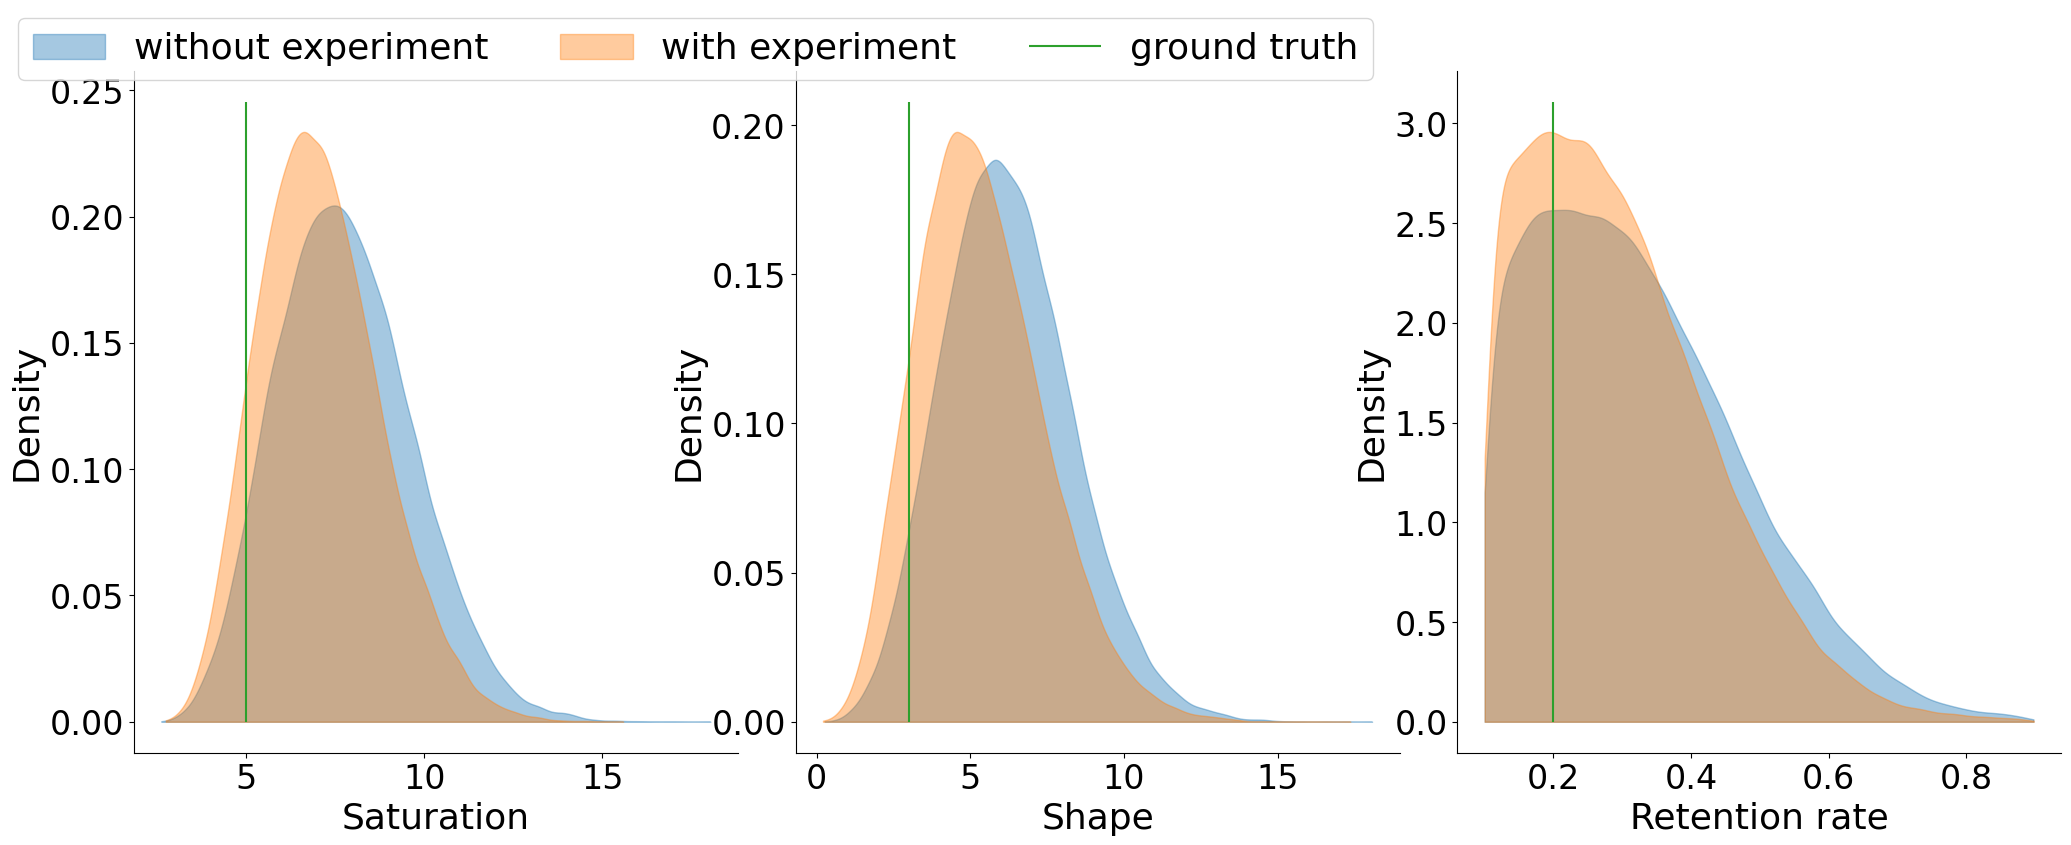

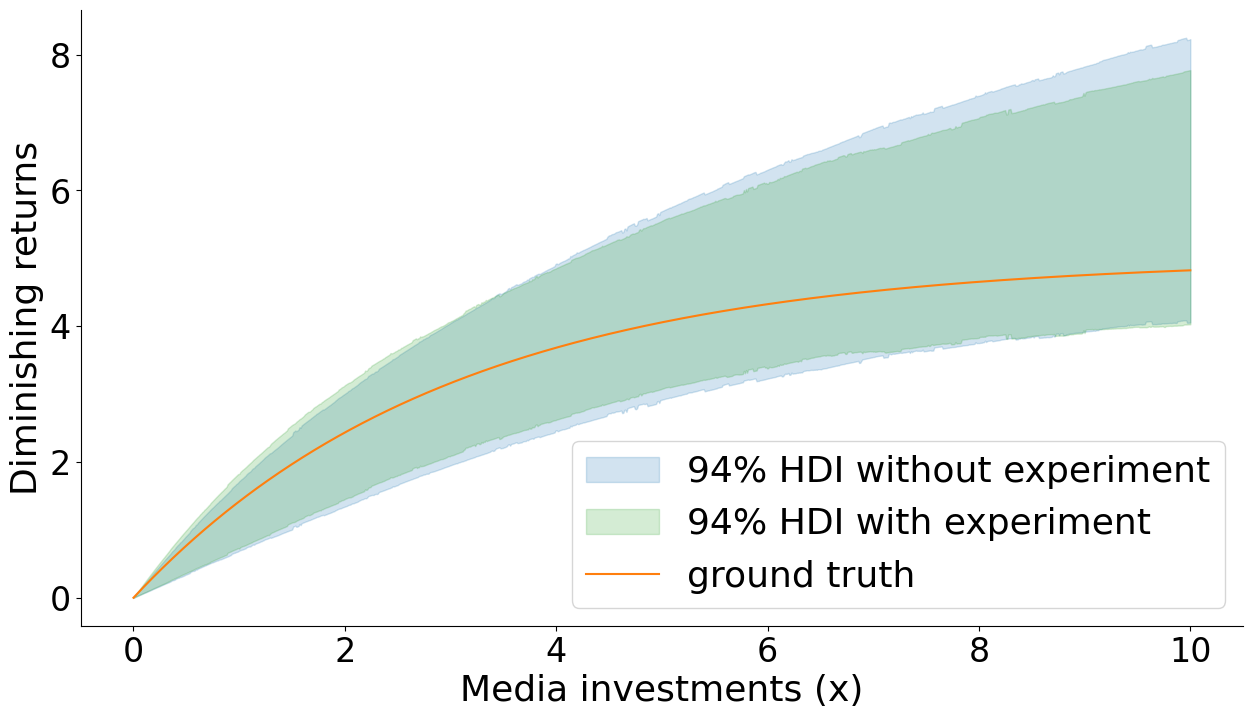

In [24]:
# Plot the stuff
plot_experiment_posterior_vs_ground_truth(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_curve_param,
    media_param_df=media_param_df,
    media_feature_names=["media_0"],
)

plot_experiment_posterior_response_curve(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_curve_param,
    media_param_df=media_param_df,
    media_feature_name="media_0",
)

### 4.2 Optimize for retention rate parameter

In [25]:
d_hat_retention_rate = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        # Let's assume that we only do the experimnent on the Channel 0.
        lower_bound=(
            future_media_data_df.with_columns(
                pl.lit(0.0).alias("media_0")
            ).to_numpy()
        ),
        upper_bound=(
            future_media_data_df.with_columns(
                pl.lit(channel_0_total_future_budget * 2).alias("media_0")
            ).to_numpy()
        ),
        total_budget=channel_0_total_future_budget * 2,
        n_design_points=4,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            # "saturation",
            # "shape",
            "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(
    f"Optimal experiment found for retention rate parameter: "
    f"{d_hat_retention_rate}"
)

# Add the experiment data to the synthetic generated dataset
d_hat_retention_rate = d_hat_retention_rate.reshape((4, -1))
generator_with_dhat_retention_rate = (
    generator
    #
    .generate_new_observation(
        x=d_hat_retention_rate[0, :],
        c=(
            future_data.slice(0, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[1, :],
        c=(
            future_data.slice(1, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[2, :],
        c=(
            future_data.slice(2, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[3, :],
        c=(
            future_data.slice(3, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
)
data_with_dhat_retention_rate = pl.concat(
    [generator_with_dhat_retention_rate.collect(), future_data.slice(4)],
    how="vertical",
)

# Fit the model again with the new data including the experiment
model_with_dhat_retention_rate = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)
idata_with_dhat_retention_rate = model_with_dhat_retention_rate.fit(
    data_with_dhat_retention_rate.drop(["y"]).to_pandas(),
    data_with_dhat_retention_rate["y"].to_pandas(),
    random_seed=42,
)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.04356874990494208
       x: [ 0.000e+00  2.777e+00 ...  2.586e+00  2.182e+00]
    nfev: 21
   maxcv: 0.0
Optimal experiment found for retention rate parameter: [0.00000000e+00 2.77669372e+00 1.71885039e+00 2.08369035e+00
 1.11022302e-16 1.49390511e+00 1.71774849e+00 2.33711187e+00
 0.00000000e+00 4.06357170e-01 1.77238275e+00 7.83413702e-01
 0.00000000e+00 1.31429086e+00 2.58588265e+00 2.18224542e+00]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 254 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [26]:
# Summary results
summary_with_dhat_retention_rate_df = az.summary(
    idata_with_dhat_retention_rate
)
# az.plot_trace(idata_with_dhat, figsize=(15, 20));

In [27]:
summary_with_dhat_retention_rate_df.reset_index().query(
    "index.isin(['retention_rates[0]', 'shapes[0]', 'saturations[0]'])"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.283,0.127,0.100,0.505,0.000,0.001,93239.0,34484.0,1.0
126,shapes[0],6.035,2.006,2.370,9.818,0.007,0.009,84137.0,38360.0,1.0
130,saturations[0],8.038,1.882,4.616,11.560,0.006,0.008,88485.0,40300.0,1.0


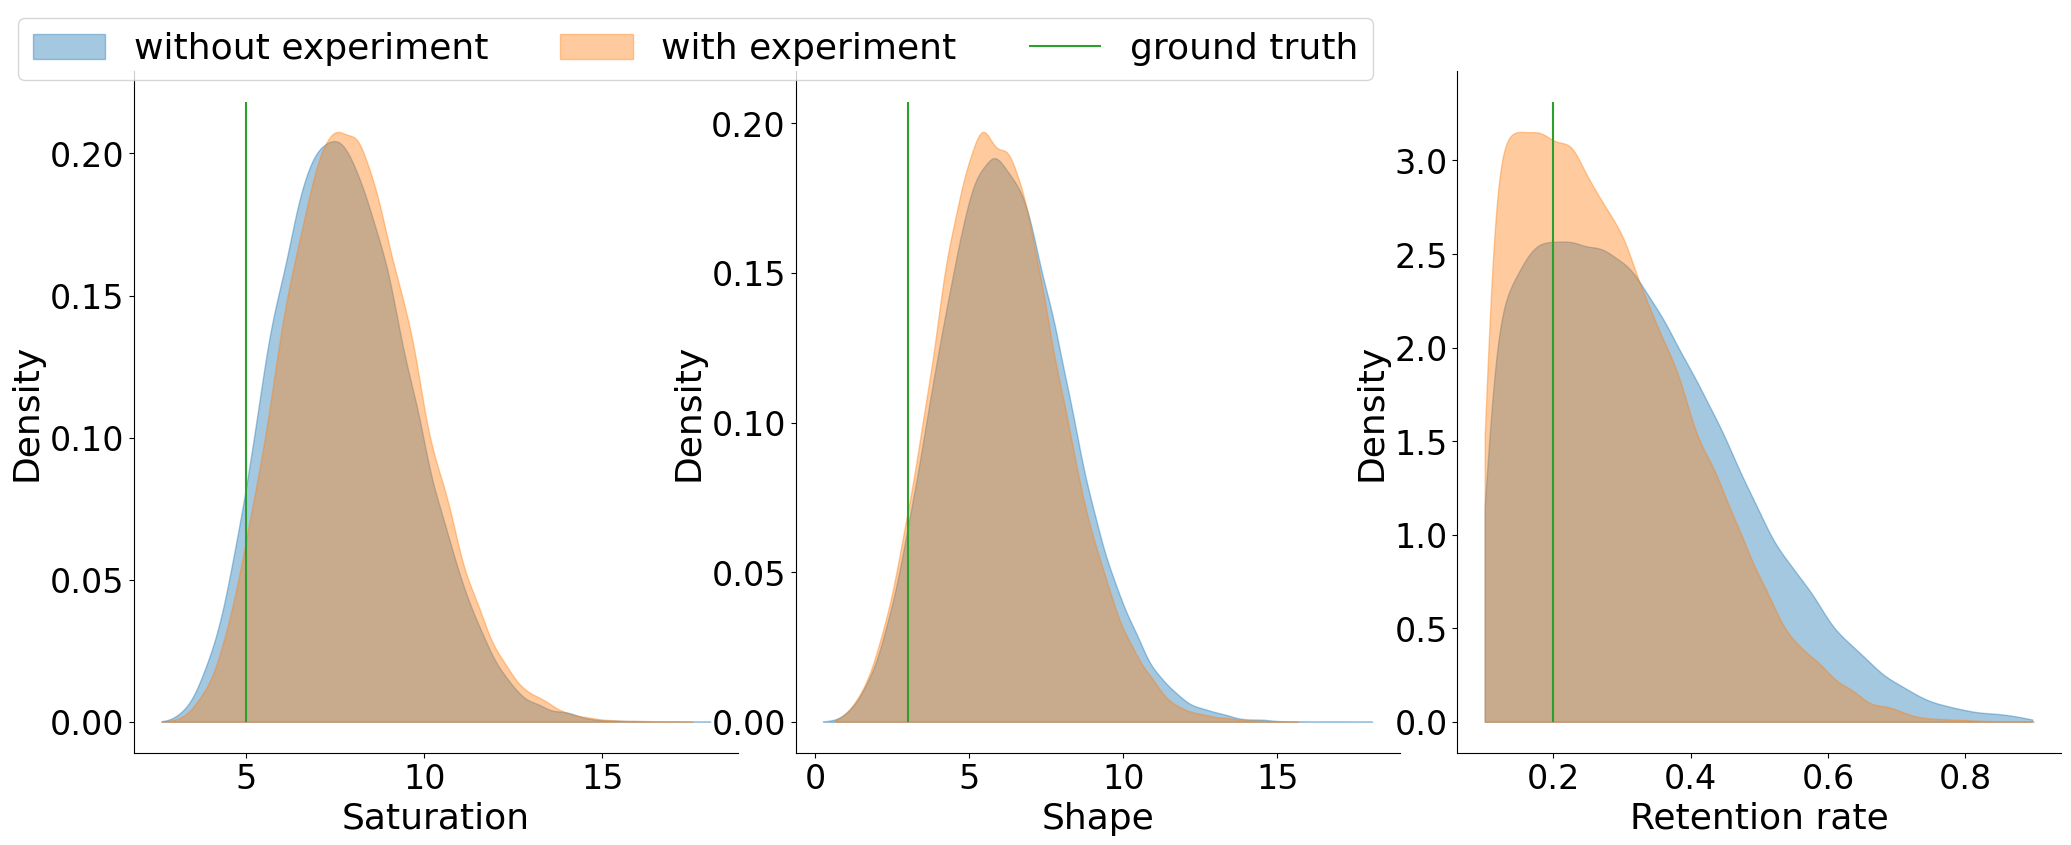

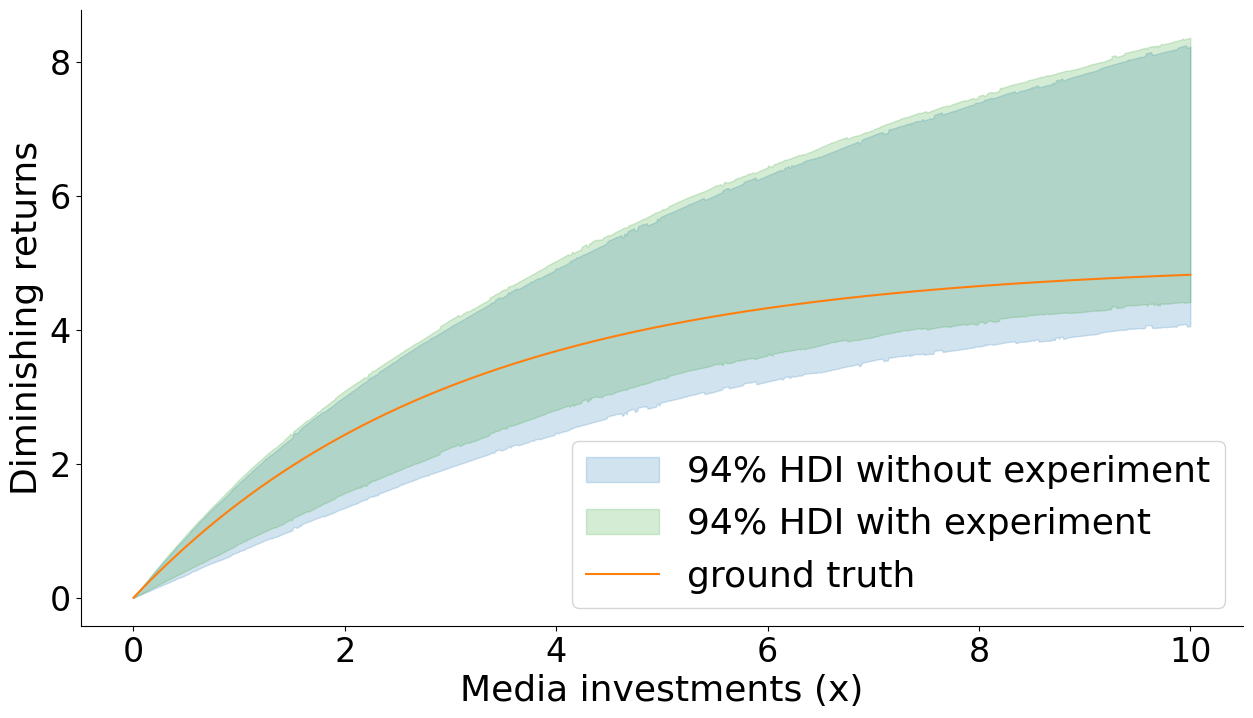

In [28]:
# Plot the stuff
plot_experiment_posterior_vs_ground_truth(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0"],
)

plot_experiment_posterior_response_curve(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_name="media_0",
)